In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load the csv files for NES
df = pd.read_csv("results_statistic_build.csv")
df['system'] = 'NebulaStream'

# Backward-compat alias: tuplesPerSecond_listener is the throughput column name
# from the new accuracy-aware build runner.
if 'tuplesPerSecond' not in df.columns and 'tuplesPerSecond_listener' in df.columns:
    df['tuplesPerSecond'] = df['tuplesPerSecond_listener']

# Extract synopsis type and variant from query_name
df["synopsis_type"] = df["query_name"].str.split("_").str[0]
df["query_variant"] = df["query_name"].str.split("_", n=1).str[1]

# Parse memory_budget into dedicated columns per statistic type.
mask_res = df["statistic_type"] == "Reservoir"
try:
    df.loc[mask_res, "reservoir_size"] = df.loc[mask_res, "memory_budget"].astype(int)
except (ValueError, KeyError):
    pass

mask_hist = df["statistic_type"] == "EquiWidthHistogram"
try:
    df.loc[mask_hist, "num_buckets"] = (
        df.loc[mask_hist, "memory_budget"]
        .str.extract(r"\((\d+),")[0].astype(int)
    )
except (ValueError, KeyError, AttributeError):
    pass

# df_ok: ok-issue subset with throughput and accuracy coerced to numeric.
# Used by every plotting cell below.
df_ok = df[df["issue"] == "ok"].copy()
df_ok["tuplesPerSecond"] = pd.to_numeric(df_ok["tuplesPerSecond"], errors="coerce")
for _col in ("point_avg_relative_error", "range_avg_relative_error"):
    if _col in df_ok.columns:
        df_ok[_col] = pd.to_numeric(df_ok[_col], errors="coerce")

df


,dataset,statistic_type,memory_budget,build_window_size_sec,executionMode,numberOfWorkerThreads,buffersInGlobalBufferManager,joinStrategy,bufferSizeInBytes,pageSize,...,run_idx,query_name,tuplesPerSecond_listener,build_duration_s,issue,system,tuplesPerSecond,synopsis_type,query_variant,reservoir_size
0,Nexmark,Reservoir,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,0,ReservoirBuild_Nexmark_1024_1sec,9.282864e+06,20.450920,ok,NebulaStream,9.282864e+06,ReservoirBuild,Nexmark_1024_1sec,1024.0
1,Nexmark,Reservoir,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,1,ReservoirBuild_Nexmark_1024_1sec,9.372577e+06,20.291688,ok,NebulaStream,9.372577e+06,ReservoirBuild,Nexmark_1024_1sec,1024.0
2,Nexmark,Reservoir,1024,1,COMPILER,1,200000,HASH_JOIN,102400,8192,...,2,ReservoirBuild_Nexmark_1024_1sec,9.205899e+06,20.573866,ok,NebulaStream,9.205899e+06,ReservoirBuild,Nexmark_1024_1sec,1024.0
3,Nexmark,Reservoir,1024,1,COMPILER,16,200000,HASH_JOIN,102400,8192,...,0,ReservoirBuild_Nexmark_1024_1sec,6.713593e+07,3.376420,ok,NebulaStream,6.713593e+07,ReservoirBuild,Nexmark_1024_1sec,1024.0
4,Nexmark,Reservoir,1024,1,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,ReservoirBuild_Nexmark_1024_1sec,6.043233e+07,3.661968,ok,NebulaStream,6.043233e+07,ReservoirBuild,Nexmark_1024_1sec,1024.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,ClusterMonitoring,Sum,1024,10,COMPILER,1,200000,HASH_JOIN,102400,8192,...,1,SumBuild_ClusterMonitoring_1024_10sec,3.114254e+06,6.595625,ok,NebulaStream,3.114254e+06,SumBuild,ClusterMonitoring_1024_10sec,NaN
392,ClusterMonitoring,Sum,1024,10,COMPILER,1,200000,HASH_JOIN,102400,8192,...,2,SumBuild_ClusterMonitoring_1024_10sec,2.929095e+06,6.907447,ok,NebulaStream,2.929095e+06,SumBuild,ClusterMonitoring_1024_10sec,NaN
393,ClusterMonitoring,Sum,1024,10,COMPILER,16,200000,HASH_JOIN,102400,8192,...,0,SumBuild_ClusterMonitoring_1024_10sec,2.759483e+07,1.226451,ok,NebulaStream,2.759483e+07,SumBuild,ClusterMonitoring_1024_10sec,NaN
394,ClusterMonitoring,Sum,1024,10,COMPILER,16,200000,HASH_JOIN,102400,8192,...,1,SumBuild_ClusterMonitoring_1024_10sec,2.660886e+07,1.329054,ok,NebulaStream,2.660886e+07,SumBuild,ClusterMonitoring_1024_10sec,NaN


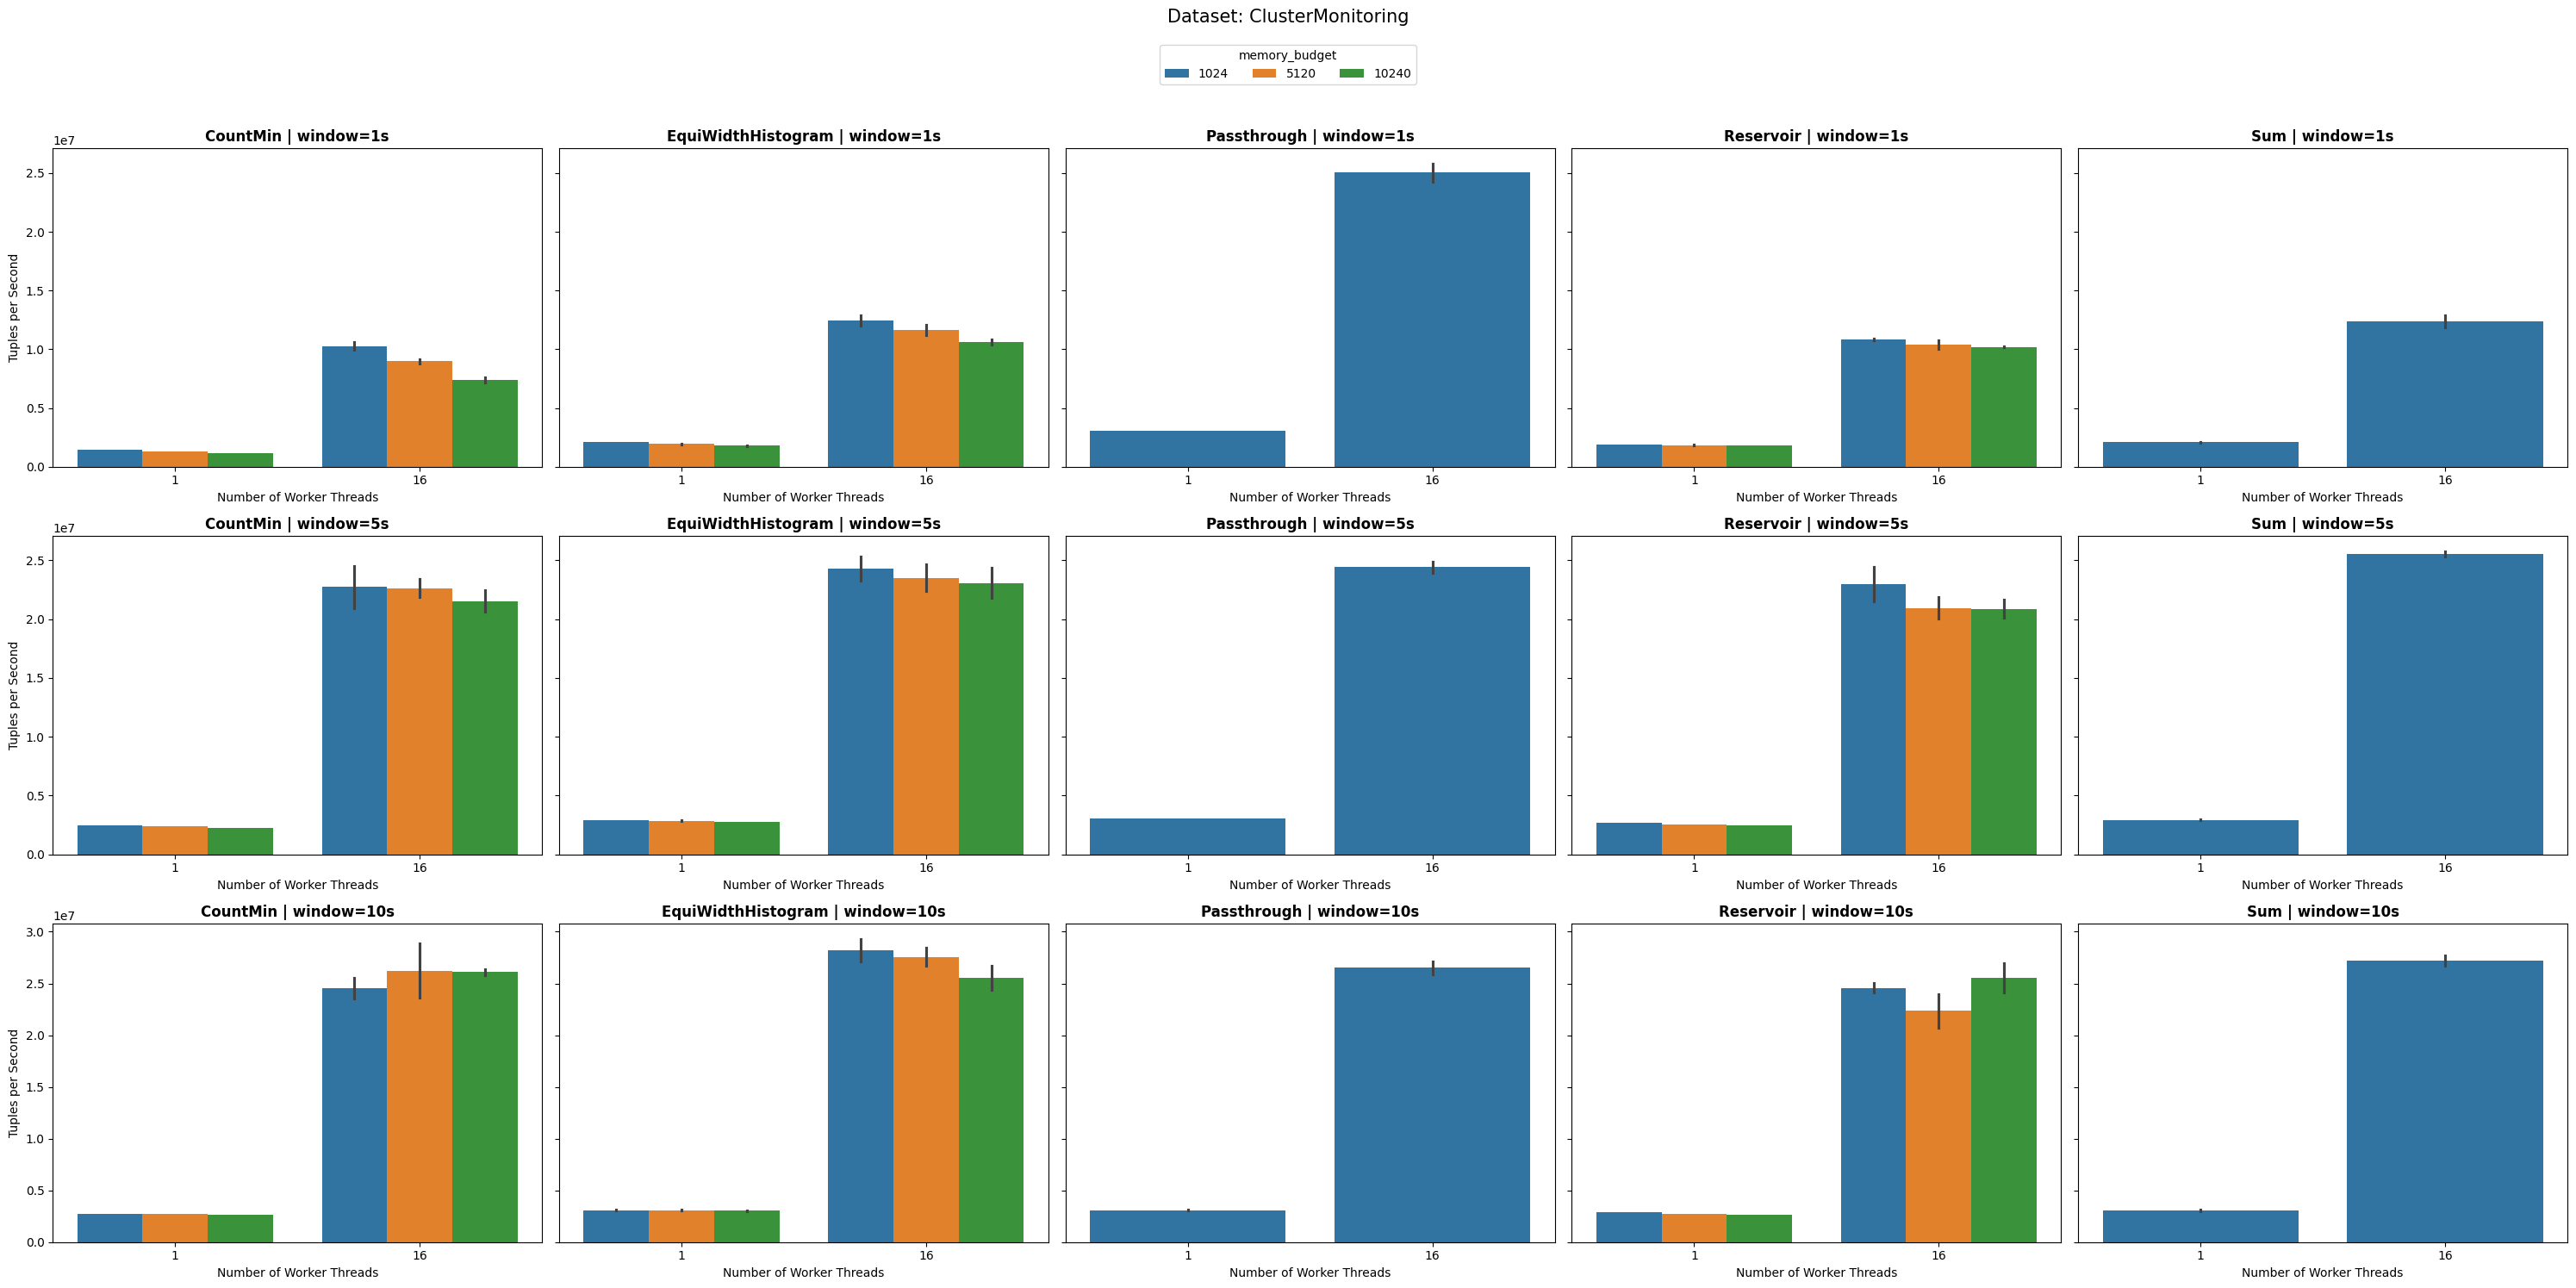

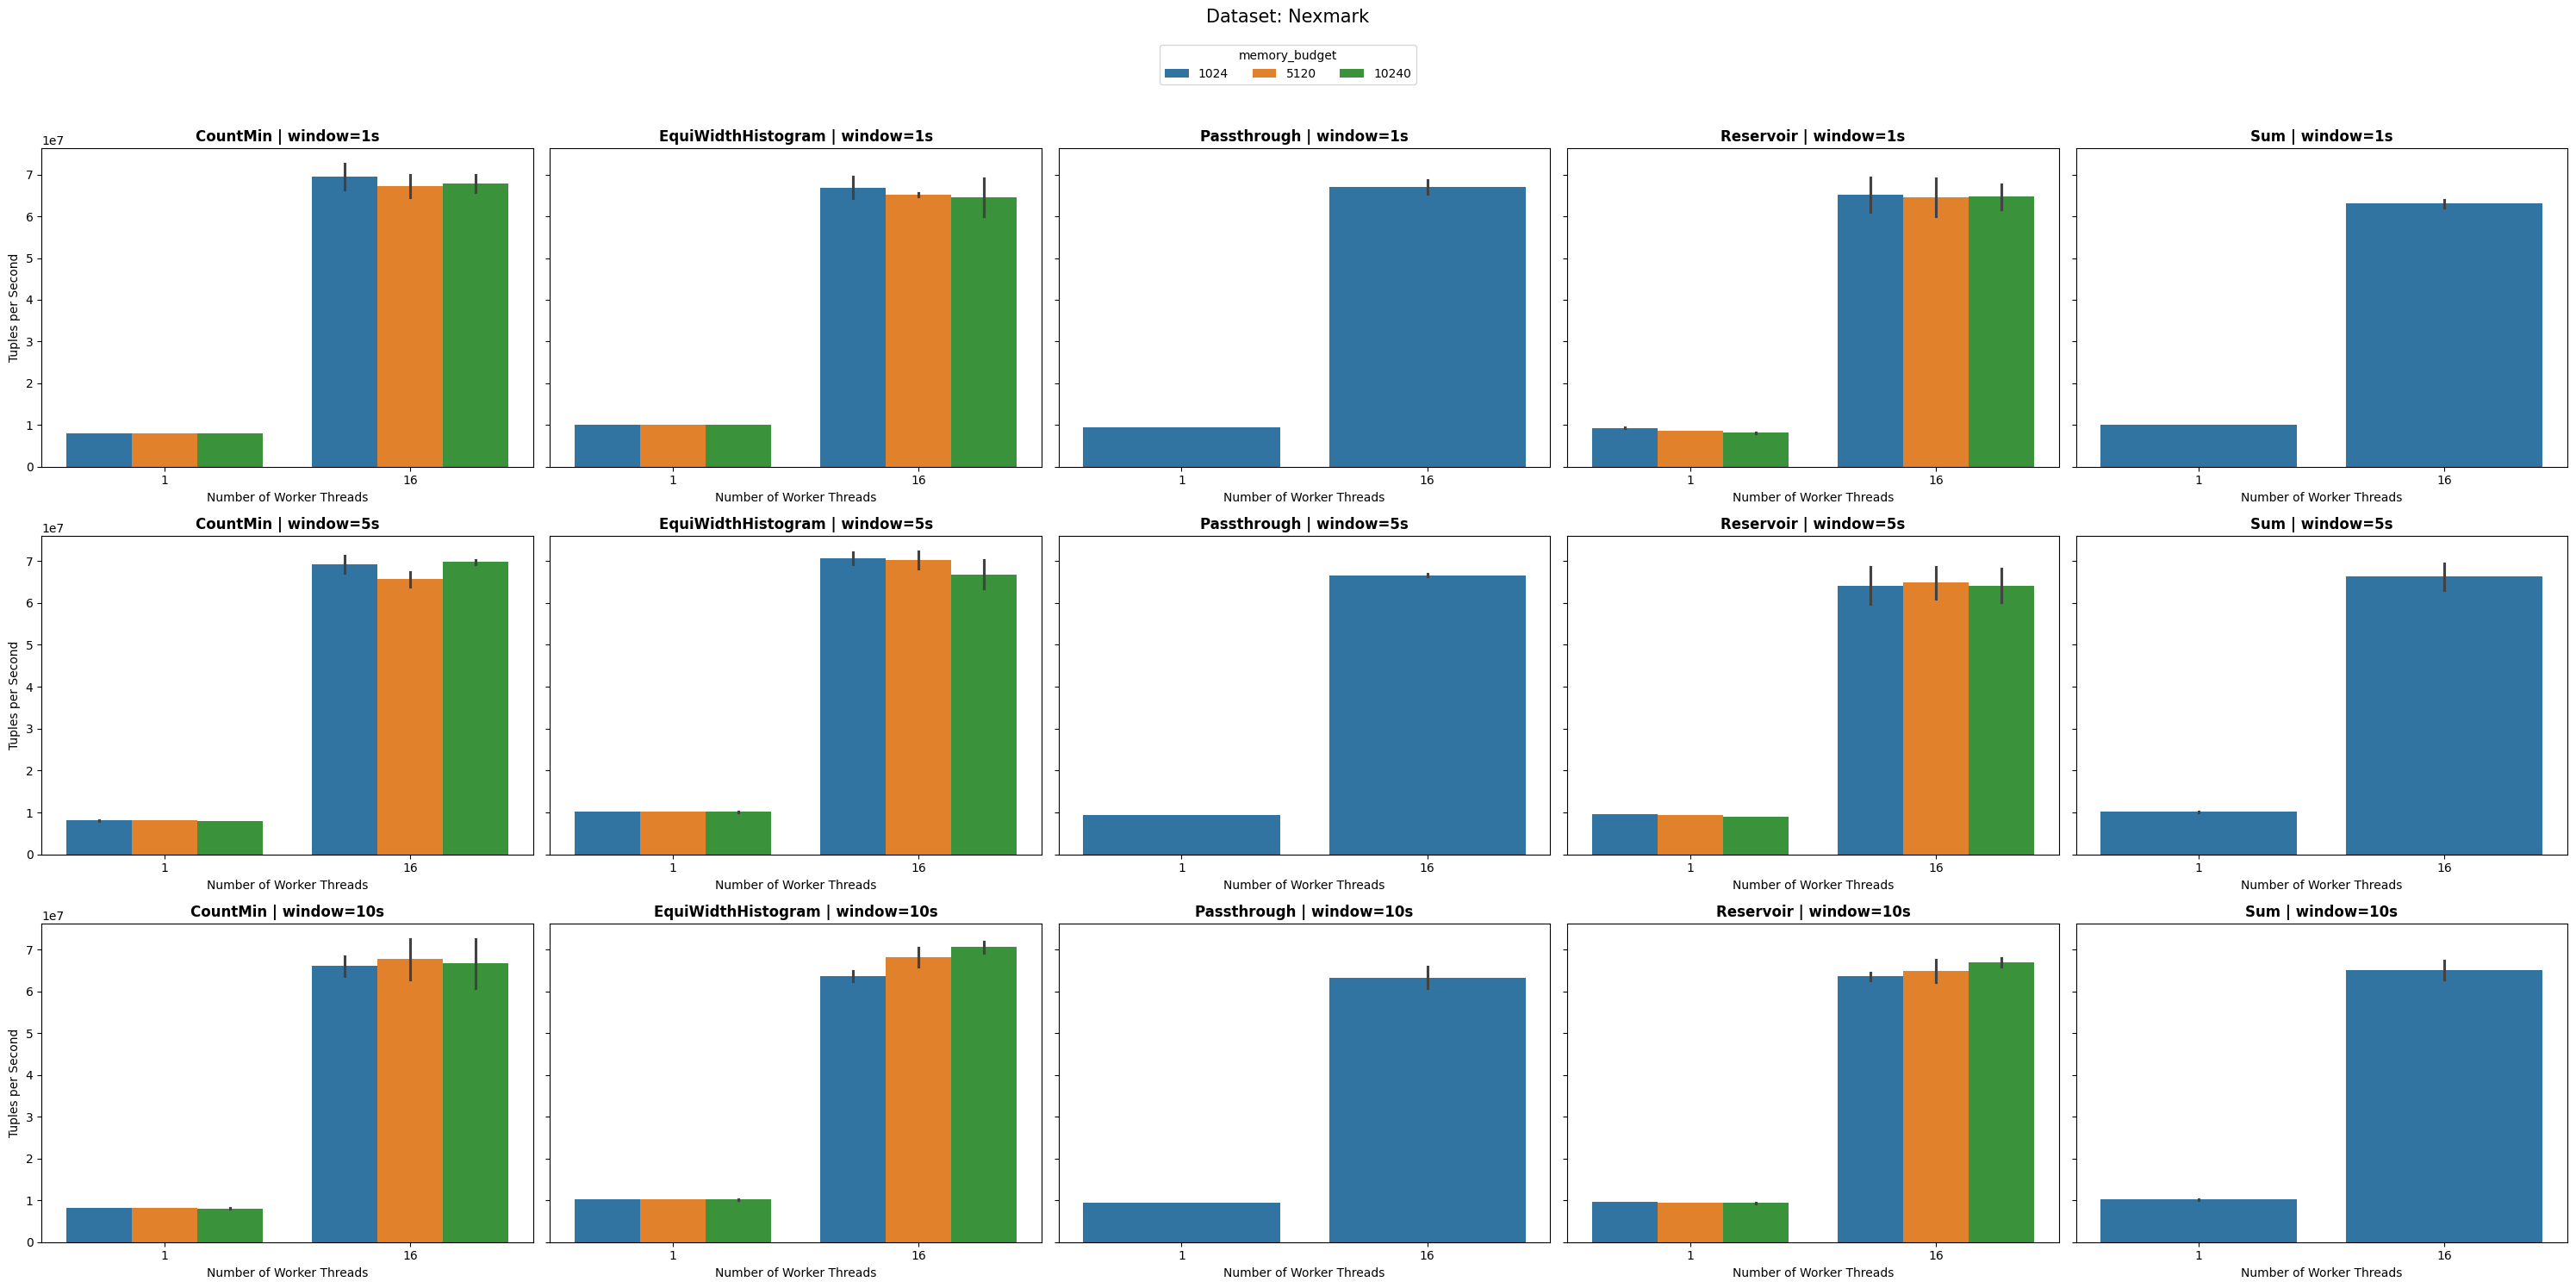

In [2]:
 # For each unique dataset, plot a grid:
  #   rows = build_window_size_sec, cols = statistic_type
  #   x = numberOfWorkerThreads, y = tuplesPerSecond

df_ok = df[df["issue"] == "ok"].copy()
df_ok["tuplesPerSecond"] = pd.to_numeric(df_ok["tuplesPerSecond"], errors="coerce")
df_ok = df_ok.dropna(subset=["tuplesPerSecond"])

# Per-row y-axis upper bound: shared across cols within a row, independent across rows.
# Add headroom for the std error bar so the whisker is not clipped.
_means = df_ok.groupby(
  ["dataset", "build_window_size_sec", "statistic_type", "memory_budget", "numberOfWorkerThreads"]
)["tuplesPerSecond"].agg(["mean", "std"]).fillna(0)
_row_top = (_means["mean"] + _means["std"]).groupby(level=["dataset", "build_window_size_sec"]).max() * 1.05

for dataset in sorted(df_ok["dataset"].unique()):
  df_ds = df_ok[df_ok["dataset"] == dataset]

  window_sizes = sorted(df_ds["build_window_size_sec"].unique())
  statistic_types = sorted(df_ds["statistic_type"].unique())

  n_rows = len(window_sizes)
  n_cols = len(statistic_types)

  fig, axes = plt.subplots(
      n_rows, n_cols,
      figsize=(6 * n_cols, 5 * n_rows),
      sharey='row',
      squeeze=False,
  )

  legend_handles, legend_labels = None, None

  for row_idx, window_size in enumerate(window_sizes):
      row_ymax = _row_top.loc[(dataset, window_size)]
      for col_idx, stat_type in enumerate(statistic_types):
          ax = axes[row_idx][col_idx]
          subset = df_ds[
              (df_ds["build_window_size_sec"] == window_size)
              & (df_ds["statistic_type"] == stat_type)
          ]

          if subset.empty:
              ax.set_visible(False)
              continue

          hue_order = sorted(subset["memory_budget"].dropna().unique())
          sns.barplot(
              data=subset,
              x="numberOfWorkerThreads",
              y="tuplesPerSecond",
              hue="memory_budget",
              hue_order=hue_order,
              palette=sns.color_palette("tab10", len(hue_order)),
              errorbar="sd",
              ax=ax,
          )

          ax.set_ylim(0, row_ymax)
          ax.set_title(f"{stat_type} | window={window_size}s", fontsize=12, fontweight="bold")
          ax.set_xlabel("Number of Worker Threads")
          ax.set_ylabel("Tuples per Second" if col_idx == 0 else "")
          handles, labels = ax.get_legend_handles_labels()
          if legend_handles is None or len(labels) > len(legend_labels):
              legend_handles, legend_labels = handles, labels
          ax.get_legend().remove()

  fig_height = fig.get_figheight()
  top_reserve = 1.0 / fig_height
  if legend_handles:
      fig.legend(
          legend_handles,
          legend_labels,
          title="memory_budget",
          loc="upper center",
          bbox_to_anchor=(0.5, 1 - 0.45 * top_reserve),
          ncol=len(legend_labels),
          fontsize=10,
      )
  fig.suptitle(f"Dataset: {dataset}", fontsize=15, y=1 - 0.1 * top_reserve)
  plt.tight_layout(rect=[0, 0, 1, 1 - top_reserve])
  plt.savefig(f"StatisticBuild_{dataset}_throughput.pdf", dpi=300, bbox_inches="tight")
  plt.show()

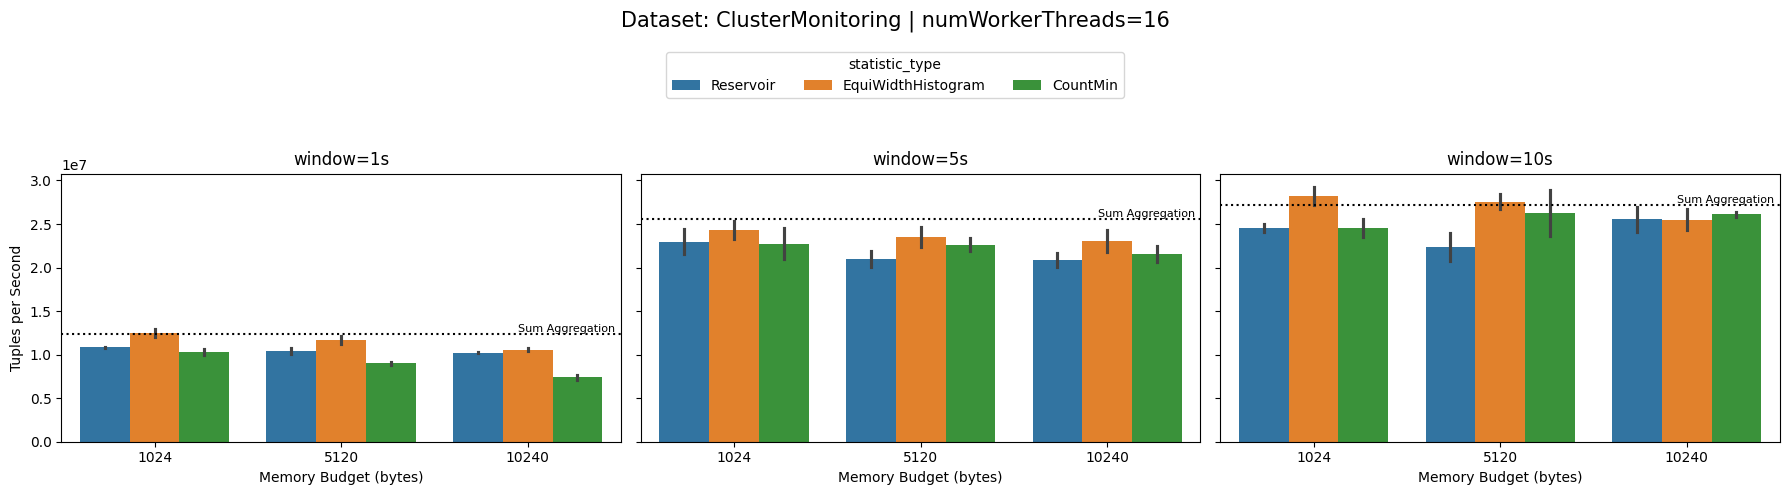

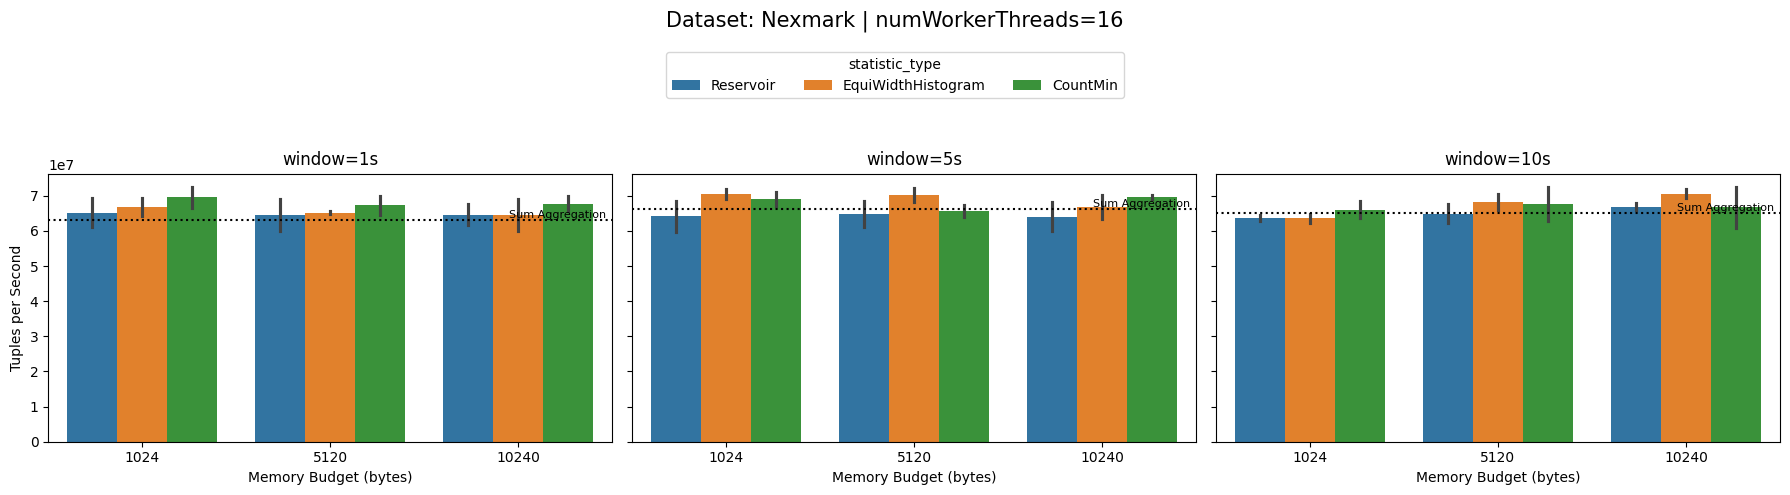

In [3]:
# memory_budget vs throughput at numberOfWorkerThreads=16.
# One line per statistic_type, faceted by build_window_size_sec.
# Sum and Passthrough bars are excluded; the Sum average is shown as a dotted reference line.
df16 = df_ok[df_ok["numberOfWorkerThreads"].astype(str) == "16"].copy()

excluded_types = {"Sum", "Passthrough"}
sum_means = (
    df16[df16["statistic_type"] == "Sum"]
    .groupby(["dataset", "build_window_size_sec"])["tuplesPerSecond"]
    .mean()
)

for dataset in sorted(df16["dataset"].unique()):
    df_ds = df16[df16["dataset"] == dataset]
    window_sizes = sorted(df_ds["build_window_size_sec"].unique())
    n_cols = len(window_sizes)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5), sharey=True, squeeze=False)
    legend_handles, legend_labels = None, None
    for col_idx, window_size in enumerate(window_sizes):
        ax = axes[0][col_idx]
        subset = df_ds[
            (df_ds["build_window_size_sec"] == window_size)
            & (~df_ds["statistic_type"].isin(excluded_types))
        ]
        if subset.empty:
            ax.set_visible(False)
            continue
        sns.barplot(
            data=subset, x="memory_budget", y="tuplesPerSecond",
            hue="statistic_type", errorbar="sd", ax=ax,
        )
        ax.set_xlabel("Memory Budget (bytes)")
        ax.set_ylabel("Tuples per Second" if col_idx == 0 else "")
        ax.set_title(f"window={window_size}s")
        handles, labels = ax.get_legend_handles_labels()
        if legend_handles is None or len(labels) > len(legend_labels):
            legend_handles, legend_labels = handles, labels
        ax.get_legend().remove()
        sum_mean = sum_means.get((dataset, window_size))
        if sum_mean is not None and pd.notna(sum_mean):
            ax.axhline(sum_mean, linestyle=":", color="black", linewidth=1.5)
            ax.text(
                0.99, sum_mean, "Sum Aggregation",
                transform=ax.get_yaxis_transform(),
                ha="right", va="bottom", fontsize=8, color="black",
            )
    fig_height = fig.get_figheight()
    top_reserve = 1.0 / fig_height
    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            title="statistic_type",
            loc="upper center",
            bbox_to_anchor=(0.5, 1 - 0.45 * top_reserve),
            ncol=len(legend_labels),
            fontsize=10,
        )
    fig.suptitle(f"Dataset: {dataset} | numWorkerThreads=16", fontsize=15, y=1 - 0.1 * top_reserve)
    plt.tight_layout(rect=[0, 0, 1, 1 - top_reserve])
    plt.savefig(f"StatisticBuild_{dataset}_memory_budget_threads16.pdf", dpi=300, bbox_inches="tight")
    plt.show()